# Simulador: cómo la regla de conteo cambia el resultado

Este cuaderno acompaña la presentación. Sirve para **mostrar en vivo** que, con
las mismas boletas, tres reglas de conteo distintas financian obras distintas —
y para dejar que quien quiera le mueva a los números.

Se comparan las tres reglas de las diapositivas:

| | Regla | Cómo funciona |
|---|---|---|
| 1 | **Conteo simple** | Voto libre, gana el más votado hasta agotar la bolsa |
| 2 | **Elecciones por distrito** | La bolsa se reparte por población y cada quien vota lo suyo |
| 3 | **Partes Iguales** | Cada votante recibe *b/n* y paga por lo que aprueba |

El escenario por defecto es **Circleville**, la ciudad de Peters et al. (2021,
Figura 1) — la misma del mapa de la diapositiva 6.

> **Cómo usarlo.** Corre las celdas en orden, empezando por la de preparación.
> Funciona igual en **Google Colab** que en una instalación local: la primera
> celda instala lo que falte y trae el código del simulador.
>
> La sección 8 tiene el tablero de sliders, y justo debajo la misma simulación
> escribiendo los números a mano, por si los widgets no responden en la máquina
> donde vayas a presentar.

In [1]:
# ══════════════════════════════════════════════════════════════════
#  Preparación — corre esta celda primero
#  Funciona igual en Google Colab que en una instalación local.
#  (Si prefieres esconderla al presentar, ponle #@title en la primera línea.)
# ══════════════════════════════════════════════════════════════════

# ── 1. Paquetes ───────────────────────────────────────────────────
# Colab ya los trae todos, así que normalmente esto no instala nada. Se revisa
# primero para no salir a la red en cada corrida.
import importlib.util

FALTAN = [m for m in ("numpy", "pandas", "matplotlib", "ipywidgets")
          if importlib.util.find_spec(m) is None]
if FALTAN:
    print("Instalando:", ", ".join(FALTAN), "…")
    %pip install -q numpy pandas matplotlib ipywidgets
else:
    print("Paquetes: ya están todos.")

# ── 2. El código del simulador ────────────────────────────────────
REPO = "https://github.com/marionomics/presupuesto-participativo.git"
RAMA = "main"

import pathlib, subprocess, sys

def _repo_local():
    """¿Estamos dentro del repo? Entonces se usa el código de aquí."""
    aqui = pathlib.Path.cwd()
    for candidato in (aqui, *aqui.parents):
        if (candidato / "pb_mes" / "demo").is_dir():
            return candidato
    return None

raiz = _repo_local()
if raiz is None:                          # Colab, o cualquier máquina sin el repo
    base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else pathlib.Path.cwd()
    raiz = base / "presupuesto-participativo"
    if not (raiz / "pb_mes" / "demo").is_dir():
        print(f"Clonando el simulador ({RAMA})…")
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", RAMA, REPO, str(raiz)],
            check=True,
        )
sys.path.insert(0, str(raiz))
print("Código del simulador:", raiz)

# ── 3. Widgets ────────────────────────────────────────────────────
try:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
    print("Widgets de Colab habilitados.")
except ImportError:
    pass                                   # fuera de Colab no hace falta

# ── 4. Lo que usa el notebook ─────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

from pb_mes.demo.escenario import circleville, escenario_simple
from pb_mes.demo.boletas import generar_boletas
from pb_mes.demo.reglas import comparar, conteo_simple, elecciones_por_distrito, partes_iguales
from pb_mes.demo import graficas
from pb_mes.demo.panel import simular, panel

print("Listo.")

Paquetes: ya están todos.
Código del simulador: /Users/marionomics/Documents/trabajo/Research/PAPERS/2026/presupuesto-participativo


Listo.


## 1. El escenario

Circleville tiene cuatro distritos de tamaño parecido, veinte proyectos con
costos muy distintos entre sí, y una bolsa de \$400,000 — un dólar por
habitante.

In [2]:
esc = circleville()
display(esc.tabla_distritos())
esc.tabla()

,distrito,población,% de la ciudad,parte proporcional,proyectos
0,Northside,120000,0.300,120000.0,4
1,Eastside,110000,0.275,110000.0,5
2,Westside,90000,0.225,90000.0,5
3,Southside,80000,0.200,80000.0,6


,proyecto,distrito,costo,tema,frontera con
0,A,Northside,50000,—,Westside
1,B,Northside,30000,—,
2,C,Northside,150000,parques,
3,D,Northside,250000,—,
4,E,Eastside,60000,—,
5,F,Eastside,10000,—,
6,G,Eastside,90000,ciclovia,
7,H,Eastside,60000,ciclovia,
8,I,Eastside,4000,—,
9,J,Southside,70000,—,


Dos detalles del mapa que van a importar más adelante:

- **A** y **P** están sobre el límite entre dos distritos. Los vecinos del otro
  lado también los quieren.
- **C** (parque infantil) y **R, S, H, G** (la ciclovía del río) interesan a
  gente repartida por toda la ciudad: los papás y los ciclistas. Son los
  *temas*.

## 2. Regla 1 — voto libre y conteo simple

Empecemos con el supuesto que usa el paper para abrir el ejemplo: cada quien
vota **sólo** por los proyectos de su propio distrito, y no hay ninguna
restricción sobre a dónde va el dinero.

In [3]:
boletas_paper = generar_boletas(esc, alpha=0.0, n_votantes=800, frontera=False)
r1 = conteo_simple(esc, boletas_paper)

print("Se financian:", ", ".join(r1.financiados))
print(f"Gasto: ${r1.gasto:,.0f} de ${esc.presupuesto:,.0f}")
print("Distritos sin un solo peso:", ", ".join(r1.distritos_sin_nada) or "ninguno")
print(f"Personas que viven en ellos: {r1.personas_sin_nada():,}")

Se financian: D, C
Gasto: $400,000 de $400,000
Distritos sin un solo peso: Eastside, Westside, Southside
Personas que viven en ellos: 280,000


Northside es el distrito más poblado, así que sus proyectos encabezan la lista
y se llevan la bolsa completa. **280 mil personas se quedan sin nada.** No hizo
falta una mayoría: bastó ser la minoría más grande.

### Un paréntesis honesto: el empate

Los cuatro proyectos de Northside reciben *exactamente* los mismos votos, así
que alguien tiene que decidir cuál va primero. Ese criterio —que casi nunca se
escribe en las reglas de operación— cambia el resultado:

In [4]:
for criterio, etiqueta in [("costo_desc", "primero lo caro"),
                           ("costo_asc",  "primero lo barato"),
                           ("id",         "alfabético")]:
    r = conteo_simple(esc, boletas_paper, desempate=criterio)
    print(f"{etiqueta:<20} → {', '.join(r.financiados):<28} "
          f"gasta ${r.gasto:>8,.0f} | sin nada: {r.personas_sin_nada():>7,} personas")

primero lo caro      → D, C                         gasta $ 400,000 | sin nada: 280,000 personas
primero lo barato    → B, A, C, I, F, E, H, T, R    gasta $ 381,000 | sin nada:  80,000 personas
alfabético           → A, B, C, E, F, G, I          gasta $ 394,000 | sin nada: 170,000 personas


Con "primero lo caro" sale el resultado que reporta el paper. Con "primero lo
barato" el presupuesto se derrama a otros distritos y la cifra de gente sin
nada baja mucho.

**Lo que no cambia** es la dirección: Northside es el 30% de la población y bajo
cualquier desempate se lleva bastante más del 30% del presupuesto. El problema
es real; su versión extrema depende del desempate.

## 3. Regla 2 — elecciones separadas por distrito

La respuesta natural: repartir la bolsa por población de antemano y que cada
quien vote sólo en su distrito. De aquí en adelante usamos el supuesto realista
—los vecinos del otro lado de la frontera **sí** quieren los proyectos de
frontera— y con α = 0.6, o sea con la mayoría de la gente movida por un tema
que cruza la ciudad y no por su colonia.

In [5]:
boletas = generar_boletas(esc, alpha=0.6, n_votantes=800)
r2 = elecciones_por_distrito(esc, boletas)

for d in esc.distritos:
    print(f"{d:<11} le tocaban ${esc.parte_proporcional(d):>8,.0f} → recibió ${r2.por_distrito[d]:>8,.0f}")
print(f"\nObras financiadas: {len(r2.financiados)}   Gasto: ${r2.gasto:,.0f}")

Northside   le tocaban $ 120,000 → recibió $  80,000
Eastside    le tocaban $ 110,000 → recibió $ 104,000
Westside    le tocaban $  90,000 → recibió $  87,000
Southside   le tocaban $  80,000 → recibió $  70,000

Obras financiadas: 10   Gasto: $341,000


Funciona para lo que fue diseñada: ningún distrito se queda sin nada. El costo
está en otro lado, y lo vemos en la sección 6.

## 4. Regla 3 — Método de Partes Iguales

Cada votante recibe \$*b/n* en una cuenta virtual y un proyecto se financia
cuando quienes lo apoyan pueden pagarlo entre ellos.

In [6]:
r3 = partes_iguales(esc, boletas)

print("Se financian:", ", ".join(sorted(r3.financiados)))
print(f"Gasto: ${r3.gasto:,.0f} de ${esc.presupuesto:,.0f}")
for d in esc.distritos:
    print(f"  {d:<11} ${r3.por_distrito[d]:>8,.0f}   (le tocarían ${esc.parte_proporcional(d):>8,.0f})")

Se financian:

 B, C, F, H, I, K, P, R, S, T
Gasto: $361,000 de $400,000
  Northside   $ 180,000   (le tocarían $ 120,000)
  Eastside    $  74,000   (le tocarían $ 110,000)
  Westside    $  87,000   (le tocarían $  90,000)
  Southside   $  20,000   (le tocarían $  80,000)


## 5. Las tres, lado a lado

Mismas boletas, tres reglas. La línea punteada marca lo que le tocaría a cada
distrito si el presupuesto se repartiera en proporción a su población.

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Conteo simple,6,"$400,000",$0,0.438,2.21,9%,1
Elecciones por distrito,10,"$341,000","$59,000",0.080,2.07,30%,1
Partes Iguales,10,"$361,000","$39,000",0.341,2.29,0%,0


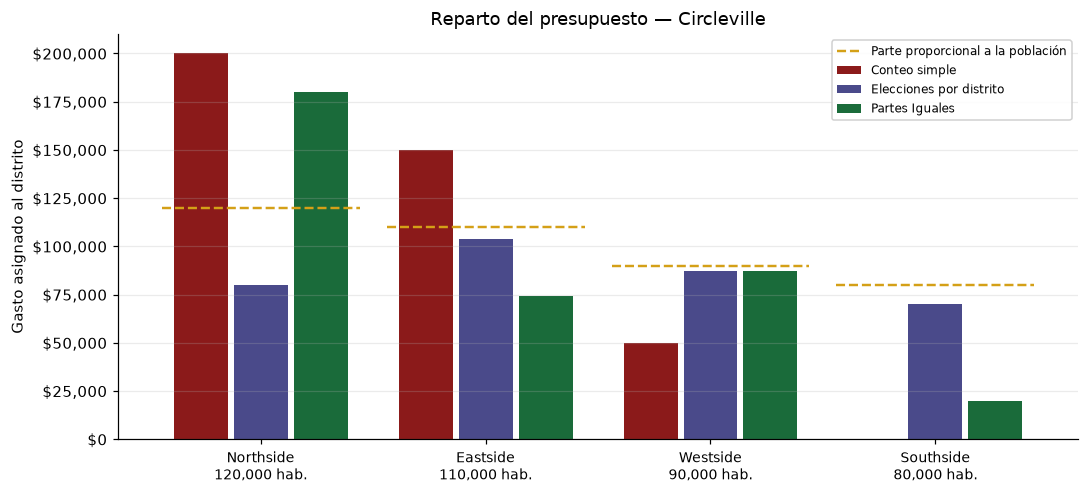

In [7]:
resultados = comparar(esc, boletas)
display(graficas.resumen(resultados))
graficas.grafica_reparto(resultados, esc)
plt.show()

In [8]:
graficas.reparto(resultados, esc)

,población,le tocaría,Conteo simple,Elecciones por distrito,Partes Iguales
distrito,,,,,
Northside,"120,000","$120,000","$200,000","$80,000","$180,000"
Eastside,"110,000","$110,000","$150,000","$104,000","$74,000"
Westside,"90,000","$90,000","$50,000","$87,000","$87,000"
Southside,"80,000","$80,000",$0,"$70,000","$20,000"


## 6. La métrica que de verdad importa

Mirando sólo la columna **Gini entre distritos**, las elecciones separadas
siempre ganan. Y tiene que ser así: reparten por distrito *por definición*.
Medir la equidad de las tres reglas con esa vara es hacer trampa a favor de una
de ellas.

La pregunta que importa es otra: **¿cuánto de lo que cada quien pidió acabó
financiado?** Ahí sí aparecen los grupos que cruzan la ciudad — los papás, los
ciclistas — que bajo elecciones separadas nunca logran juntar sus votos.

In [9]:
graficas.tabla_grupos(resultados)

,votantes,Conteo simple,Elecciones por distrito,Partes Iguales
grupo,,,,
Temático · ciclovia,240,4.0,3.0,3.0
Temático · parques,238,1.0,0.0,1.0
Vecinos · Eastside,93,2.0,3.0,3.0
Vecinos · Northside,93,2.0,2.0,2.0
Vecinos · Southside,69,0.0,2.0,2.0
Vecinos · Westside,67,3.0,5.0,4.0


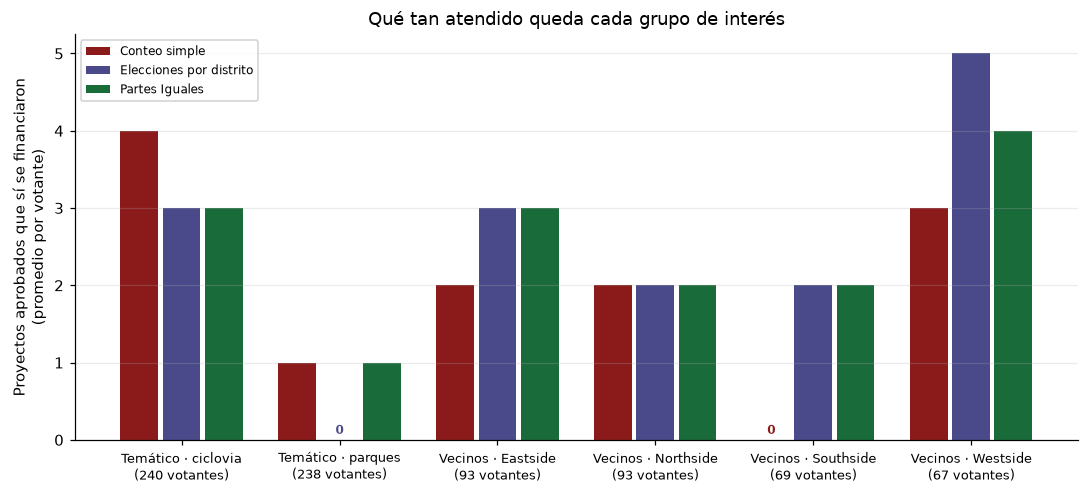

Conteo simple                   9% de votantes sin nada   grupos vacíos: Vecinos · Southside
Elecciones por distrito        30% de votantes sin nada   grupos vacíos: Temático · parques
Partes Iguales                  0% de votantes sin nada   grupos vacíos: —


In [10]:
graficas.grafica_satisfaccion(resultados)
plt.show()

for r in resultados:
    vacios = r.grupos_sin_nada()
    print(f"{r.regla:<28} {r.sin_nada:>5.0%} de votantes sin nada   "
          f"grupos vacíos: {', '.join(vacios) if vacios else '—'}")

Un cero en esa tabla es un grupo entero al que no le financiaron **ni un solo
proyecto**. Eso es exactamente lo que la propiedad EJR promete evitar, y es la
razón de la garantía de la diapositiva 21.

**Dos objeciones que conviene tener contestadas:**

*"Pero el Método de Partes Iguales le da a Southside mucho menos de lo que le
tocaba por población."* Cierto, y no es un defecto: con α = 0.6 la mayoría de
los habitantes de Southside no vota por obras de Southside, vota por el parque o
por la ciclovía. Se les está atendiendo por su tema, no por su domicilio. El
grupo *Vecinos · Southside* —los que sí votaron territorialmente— queda bien
servido en la tabla de arriba.

*"Bájale el α y el grupo de los papás también se queda en cero bajo Partes
Iguales."* También cierto. Con pocos papás, el grupo no llega a juntar los
\$150,000 que cuesta el parque, y el método no se los regala. EJR garantiza que
un grupo obtenga **lo que su tamaño alcanza a pagar**, no todo lo que pida. Es
la diferencia entre proporcionalidad y complacencia — y es un buen momento para
decirlo en voz alta.

Prueba a mover el α en la sección 8 y observa dónde está el umbral.

## 7. El sobrante

El Método de Partes Iguales se detiene cuando **nadie puede pagar**, no cuando
se acaba el dinero. Qué hacer con el resto es una decisión aparte, y no es
inocente:

- **Subir la dotación pareja** — a todos se les agranda la cuenta virtual en la
  misma medida, hasta el máximo que siga cabiendo en la bolsa. Conserva la
  proporcionalidad. *Es el que viene por defecto.*
- **Repartir por número de apoyos** — simple, pero le entrega el sobrante al
  grupo más numeroso y deshace buena parte de lo ganado.
- **No completar** — lo que reportan los ejemplos del paper.

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Partes Iguales (sin completar),8,"$191,000","$209,000",0.399,1.79,30%,1
Partes Iguales (completado codicioso),11,"$391,000","$9,000",0.434,2.52,30%,1
Partes Iguales,10,"$361,000","$39,000",0.341,2.29,0%,0


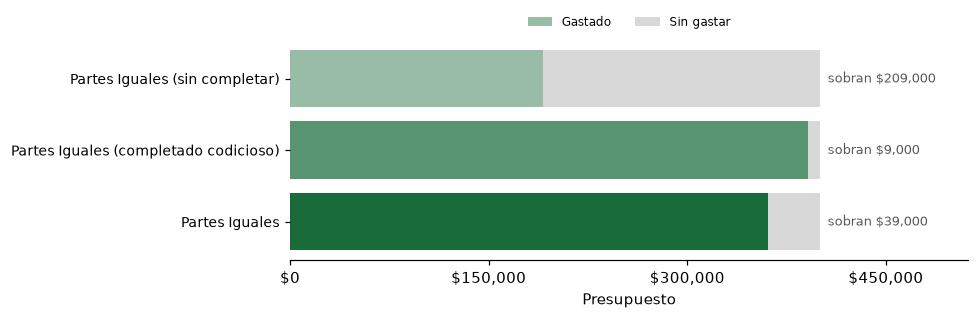

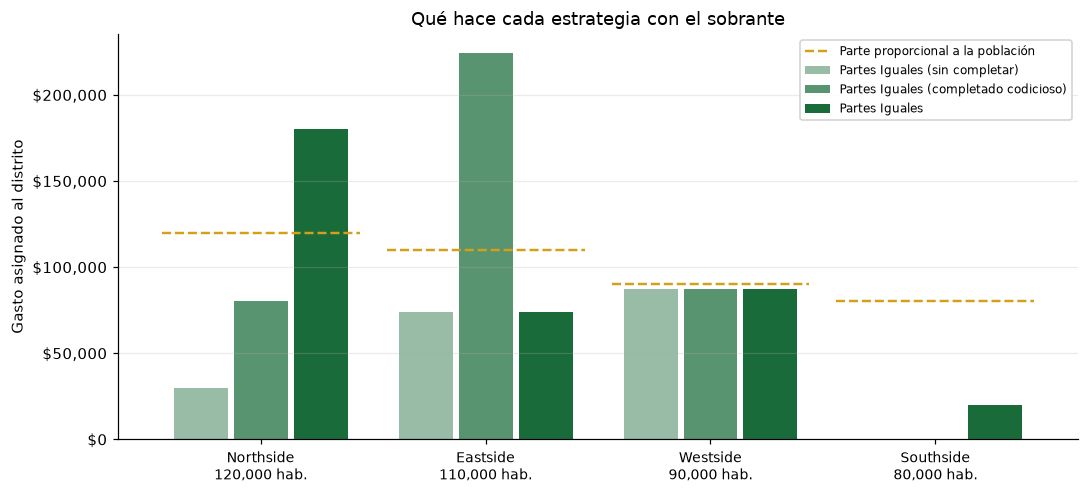

In [11]:
variantes = [partes_iguales(esc, boletas, c) for c in ("no", "codicioso", "presupuesto")]
display(graficas.resumen(variantes))
graficas.grafica_remanente(variantes)
plt.show()
graficas.grafica_reparto(variantes, esc, titulo="Qué hace cada estrategia con el sobrante")
plt.show()

## 8. Juega con los números

Mueve lo que quieras. Con **cuatro distritos** se usa Circleville, con sus
proyectos, temas y fronteras; con cualquier otro número se arma una ciudad
genérica de cuatro obras por distrito (sin temas, así que α deja de aplicar).

Cosas que vale la pena probar en vivo:

- Sube la población de un distrito muy por encima de los demás y mira el
  **conteo simple**.
- Sube **α** hasta 0.6 y compara los grupos temáticos entre las tres reglas.
- Cambia el sobrante a *"repartir por número de apoyos"* y mira cómo empeora el
  reparto del Método de Partes Iguales.
- Sube el **costo de las obras** hasta que casi nada quepa en la bolsa.

In [12]:
panel()

> ### ⚠️ ¿El tablero de arriba no pintó, o no reacciona?
>
> Pasa a veces en Colab, sobre todo si la sesión se reconectó. **No pierdas
> tiempo en vivo:** usa la celda de aquí abajo, que hace exactamente lo mismo
> escribiendo los números a mano. Edita los valores y córrela.
>
> *(Si quieres intentar arreglar el tablero: Entorno de ejecución → Reiniciar
> sesión, y vuelve a correr desde la celda de preparación.)*

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Conteo simple,6,"$400,000",$0,0.438,2.21,9%,1
Elecciones por distrito,10,"$341,000","$59,000",0.080,2.07,30%,1
Partes Iguales,10,"$361,000","$39,000",0.341,2.29,0%,0


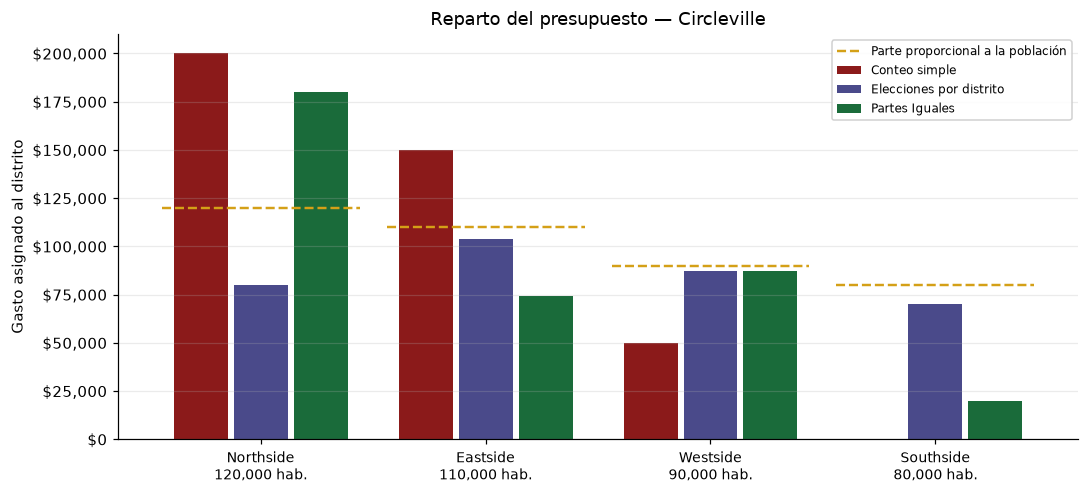

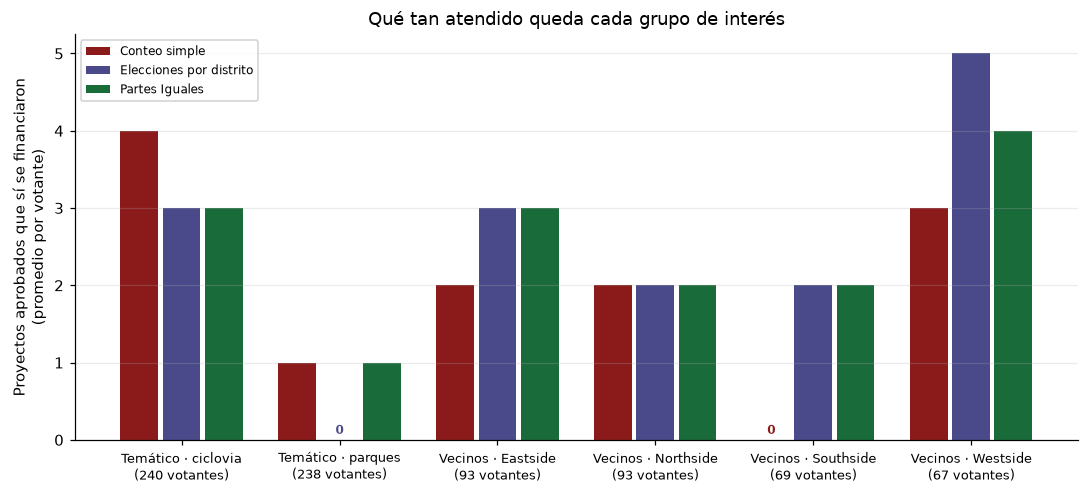

In [13]:
esc_x, boletas_x, resultados_x = simular(
    poblacion   = [120_000, 110_000, 90_000, 80_000],   # un valor por distrito
    presupuesto = 400_000,
    alpha       = 0.6,         # 0 = todo el interés es de la propia colonia
    completar   = "presupuesto",   # "presupuesto" | "codicioso" | "no"
    desempate   = "costo_desc",    # "costo_desc" | "costo_asc" | "id"
    factor_costos = 1.0,
    n_votantes  = 800,
)

## 9. Tres escenarios listos para la presentación

### A. La minoría más grande
Un distrito con el doble de habitantes que los demás.

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Conteo simple,7,"$394,000","$6,000",0.608,2.50,0%,0
Elecciones por distrito,9,"$381,000","$19,000",0.284,2.33,0%,0
Partes Iguales,11,"$391,000","$9,000",0.382,3.17,0%,0


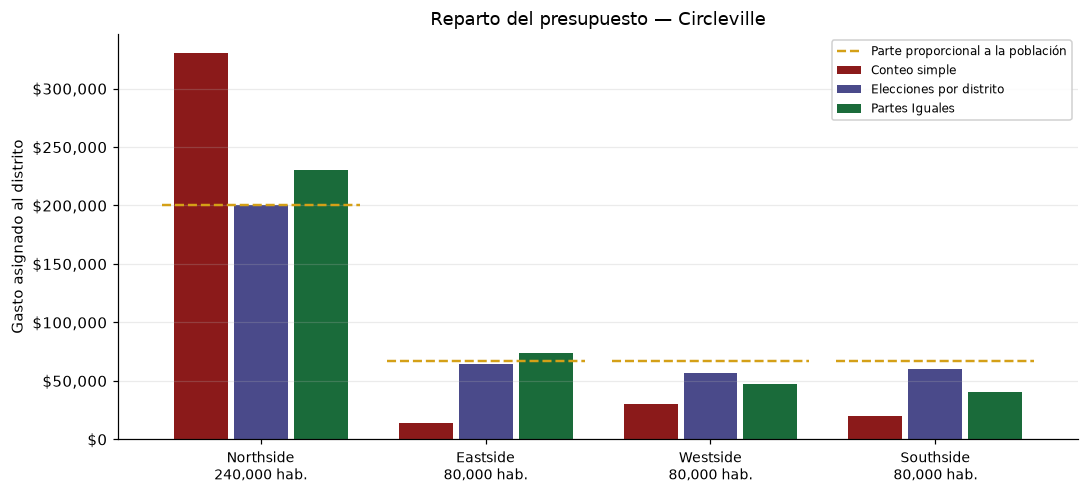

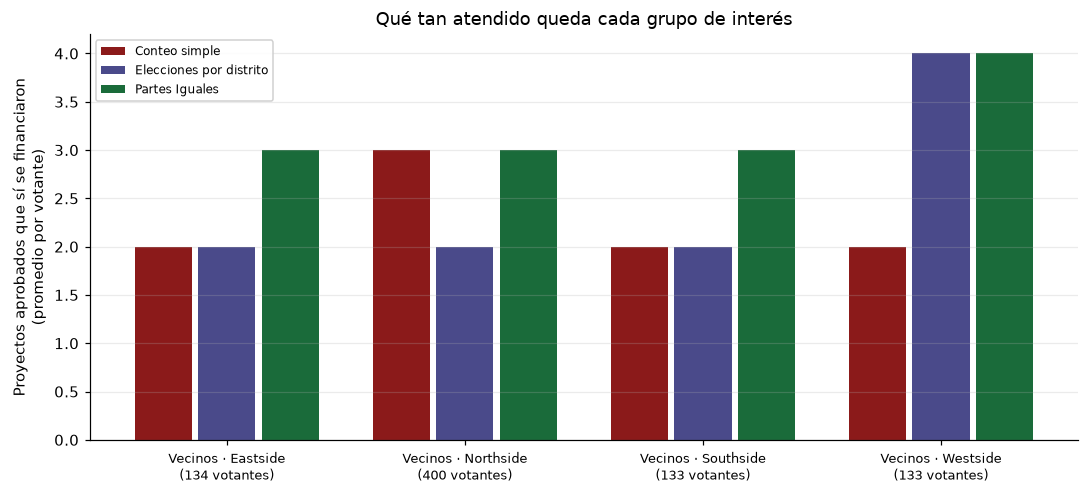

In [14]:
_ = simular(poblacion=[240_000, 80_000, 80_000, 80_000], alpha=0.0)

### B. Intereses que cruzan la ciudad
Distritos parejos, pero la mayoría de la gente vota por tema y no por colonia.

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Conteo simple,8,"$397,000","$3,000",0.342,2.41,0%,0
Elecciones por distrito,9,"$367,000","$33,000",0.050,1.87,36%,1
Partes Iguales,9,"$331,000","$69,000",0.304,2.15,0%,0


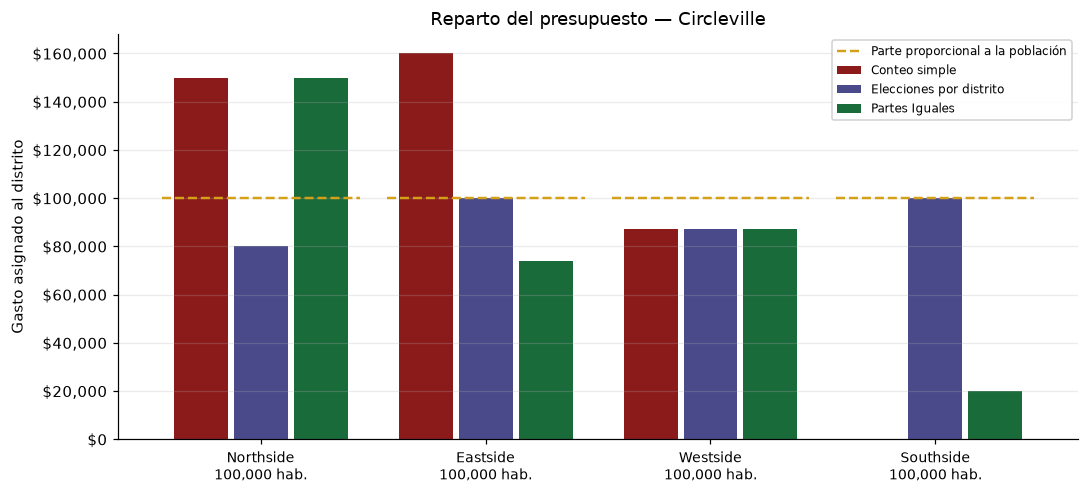

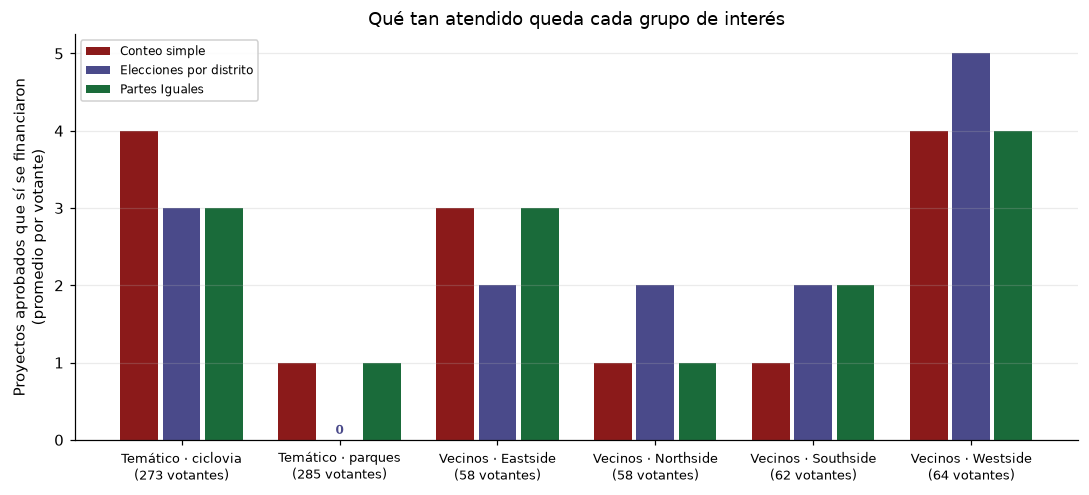

In [15]:
_ = simular(poblacion=[100_000] * 4, alpha=0.7)

### C. Muchos distritos chicos
Ocho distritos, uno grande y siete pequeños. Sin temas: aquí todo es territorio.

,obras financiadas,gasto,remanente,Gini entre distritos,satisfacción media,votantes sin nada,grupos sin nada
regla,,,,,,,
Conteo simple,8,"$600,000",$0,0.604,2.00,33%,4
Elecciones por distrito,11,"$600,000",$0,0.292,2.25,0%,0
Partes Iguales,11,"$425,000","$175,000",0.463,2.25,0%,0


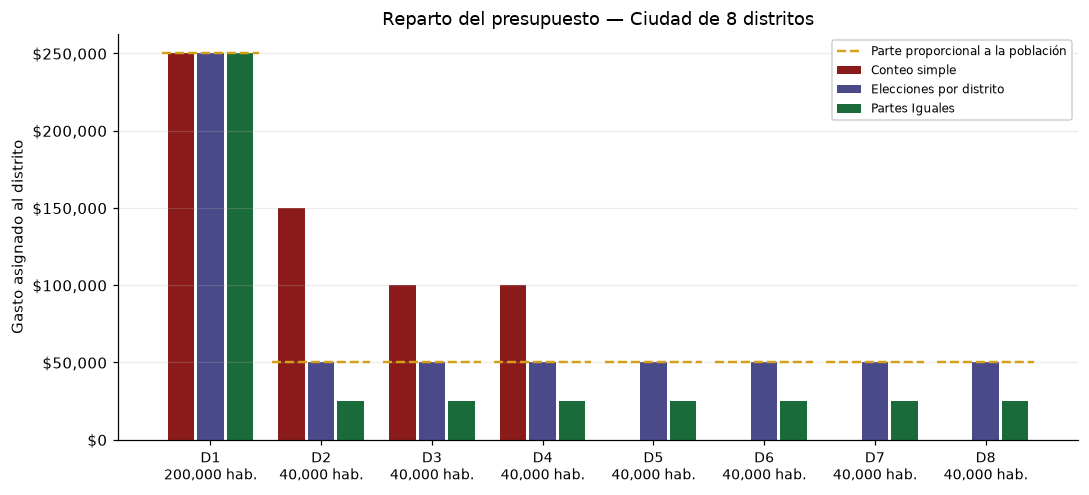

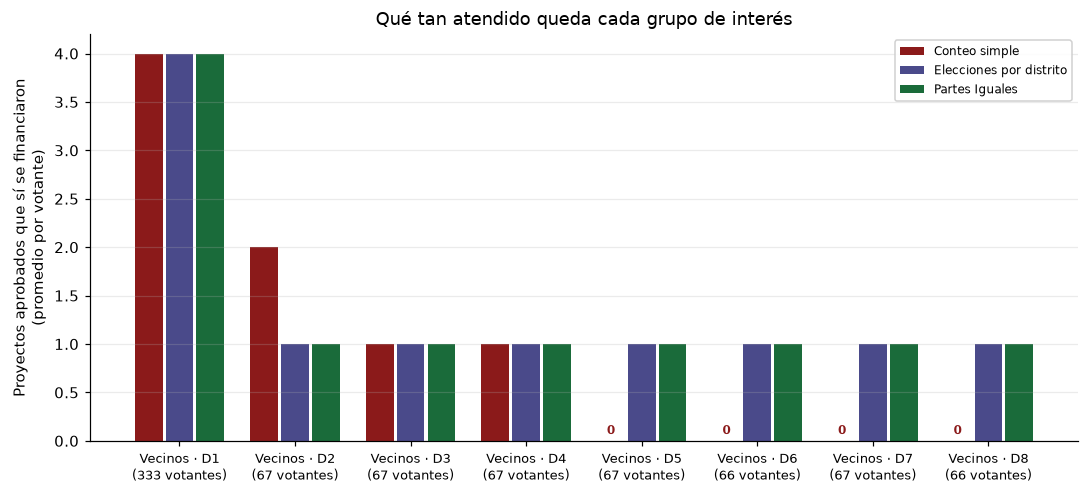

In [16]:
_ = simular(poblacion=[200_000] + [40_000] * 7, presupuesto=600_000)

---

### Notas

- **Fuente.** D. Peters, G. Pierczyński y P. Skowron, *Proportional Participatory
  Budgeting with Additive Utilities*, NeurIPS 2021 (arXiv:2008.13276v2). El
  escenario, los costos, los temas y los proyectos de frontera salen de la
  Figura 1 y del texto de la p. 2.
- **El motor está verificado contra el paper.** `tests/test_demo_reglas.py`
  comprueba que reproduce el ejemplo trabajado de las pp. 7–8: ρ = 7.2, 6, 5, 6, 6
  en la primera ronda y resultado *W* = {Proyecto 3, Proyecto 5} con \$49 de
  \$100 gastados.
- **Los votantes son simulados.** Las boletas se generan con el modelo de la
  sección 2; no son datos de ninguna elección real.

#### Para correrlo

| Dónde | Qué hacer |
|---|---|
| **Colab** | Abrir el `.ipynb` y correr la celda de preparación. Clona el código de `github.com/marionomics/presupuesto-participativo`. |
| **Local** | `.venv/bin/jupyter lab presentation/simulador.ipynb` — la celda de preparación detecta el repo y no clona nada. |
| **Pruebas** | `pytest tests/` desde la raíz del proyecto. |